# **NYT Crosswords - Skill Evolution**

I have been a diligent solver of the NYT daily crosswords for over 10 years now. 

I was introduced to American style crosswords during my Michigan days with the daily crossword in the Michigan Daily. I subscribed to New York Times and started solving their crosswords in 2016. I was able to solve the early-week puzzles (Mon-Wed) reasonably well but struggled with late-week puzzles. In an attempt to get better at the Fri/Sat themeless puzzles, I started solving some puzzles from the archives.

At some point, this turned into a methodical process where, in addition to solving the day's xword, I would also solve a couple from the archive. And, one fateful day, the thought came unbidden into my head that I should solve _all_ the puzzles available in the archive before my 40th birthday (which was then a couple of years away). And the rest, as they say, is history!!!

Between these archival solves and the daily ones, I now have a dataset of nearly 12,000 solved puzzles. This project is an attempt to track how my crossword solving time has evolved over the years and learn some regression modeling in the process.

Note: Outputs from some of the cells below have been removed because they contain widgets that don't play nicely with Github hosting

<a id="top"></a>

**Contents**

1. [The Modeling Task](#modeling-task)
2. [Data at a Glance](#data)
3. [A Simple OLS Model](#ols)
4. [Mixed-effect Modeling](#mixed)
5. [Bayesian Models](#bayesian)
6. [Model Interpretation](#interpretation)
7. [Compare Models](#compare)
8. [Prediction Breakdown](#breakdown)
9. [Big Takeaways](#takeaways)
10. [What Next](#next)


<a id="modeling-task"></a>

## The Modeling Task

The time it takes for me to solve any given crossword depends on a bunch of different factors.


*   My innate **crossword solving ability** (which is what we are trying to model)
*   **Day of the week**. Monday crosswords are easiest and the difficulty steadily increases through the week with Saturdays being toughest. Sundays are comparable to Thursdays in difficulty (a cool outcome of this exercise is presenting mathematical evidence of this fact) but feature a larger grid
*   **Puzzle fustiness**. Solving a puzzle from 1995 in 2021 introduces some "fustiness". The grid might feature answers that were popular back then but are no longer in vogue. Also, older crosswords were objectively harder (obscure proper nouns, difficult crossings, lots of crosswordese, and tougher cluing overall). For instance, the kind of entries that show up disproportionately in older grids (ESNE, SMEE, ETUI, ADIT, ONAGER ...) has fallen out of favor as editors modernized the fill. Add to that dated proper nouns (bygone actors, defunct brands, Cold-War-era geography such as USSR/SSR/ULAN), references to news cycles long past, and cluing conventions that leaned more on rote trivia and less on the wordplay and misdirection that define modern puzzles. A 1995 grid solved in 2021 is hard on two counts: its vocabulary is stale *and* its cluing plays harder.
*   **Puzzle constructor**. Some constructors are known for their brutal grids while others play easier. But this is a difficult signal to learn because the vast majority of constructors would have been published only a handful of times (often just once)
*   **Puzzle attributes**. How difficult is the fill and the cluing? Are there difficult words, tricky clues, misdirection? This is nearly impossible to quantify and I have some limited proxies for this.
*   **Everything else**!! The signal here is inherently noisy with solve times being impacted by any number of other variables. Maybe I had a headache while solving one day, maybe I knew an obscure, long answer down cold which opened up the entire grid.


We have relatively few parameters and lots of data to estimate them with. Lets try to build interpretable models that can isolate the evolution of my crossword solving ability while controlling for each of these confounding factors.

In [35]:
#@title Install necessary packages
#%pip install -r requirements.txt

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
import itertools
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from patsy import dmatrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.frameon": False,
})
%matplotlib inline

# ----------------------------------------------------------------------
# Shared constants used across the OLS, mixed-effects and Bayesian sections.
# Defining them once here keeps colours and labels consistent everywhere and
# avoids the copy-paste redundancy of the original per-section notebooks.
# ----------------------------------------------------------------------
PALETTE = {
    "ols":     "#4c72b0",   # blue   - OLS
    "mixed":   "#dd8452",   # orange - mixed effects
    "bayes":   "#55a868",   # green  - Bayesian
    "primary": "#008b8b",   # darkcyan - single-model highlight
    "accent":  "#c44e52",   # crimson
    "muted":   "#708090",   # slategray
    "start":   "#009E73",   # journey-start marker
    "archive": "#D55E00",   # archive-sweep markers
    "pos":     "#c44e52",   # slower than average
    "neg":     "#55a868",   # faster than average
}
day_labels_full = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                   'Friday', 'Saturday', 'Sunday']

<a id="data"></a>
[&#8593; Back to top](#top)

## Data at a Glance

Load all the puzzle data. There is a small fraction of puzzles that are missing some puzzle features. Remove them and sort the remaining rows by order of date of solving.

In [36]:
#@title Read xword solve times data
df = pd.read_csv("solve_data/DataForModeling_Upto2025.csv")

df['PuzzleDate'] = pd.to_datetime(df['PuzzleDate'], format="%d-%m-%Y", errors='coerce')
df['SolveDate']  = pd.to_datetime(df['SolveDate'],  format="%d-%m-%Y", errors='coerce')

continuous_features = ['AvgWordLen', 'P90ScrabbleScore']
required = ['PuzzleDate', 'SolveDate', 'SolveTime', 'PuzzleDay', 'Constructor'] + continuous_features

before_rows = len(df)
df = df.dropna(subset=required).reset_index(drop=True)
after_rows = len(df)

print(f"Historic data prepared. Dropped {before_rows - after_rows} rows with missing fields.")
print(f"Total historic rows: {after_rows}")

df = df[['PuzzleDate','SolveDate','PuzzleDay','SolveTime','AvgWordLen','P90ScrabbleScore','Constructor']]

Historic data prepared. Dropped 0 rows with missing fields.
Total historic rows: 11661


In [37]:
df.head()

,PuzzleDate,SolveDate,PuzzleDay,SolveTime,AvgWordLen,P90ScrabbleScore,Constructor
0,2016-06-01,2016-06-01,Wednesday,466,4.769231,2.075,Wren Schultz
1,2016-06-02,2016-06-02,Thursday,1062,5.153846,3.000,Susan Gelfand
2,2013-05-16,2016-06-02,Thursday,764,5.175676,2.650,Brendan Emmett Quigley and Elizabeth Donovan
3,2016-06-06,2016-06-06,Monday,328,4.846154,2.130,Mary Lou Guizzo
4,2016-06-05,2016-06-06,Sunday,952,5.152174,2.200,Tom McCoy


### Solve history

This is how my solving journey looks

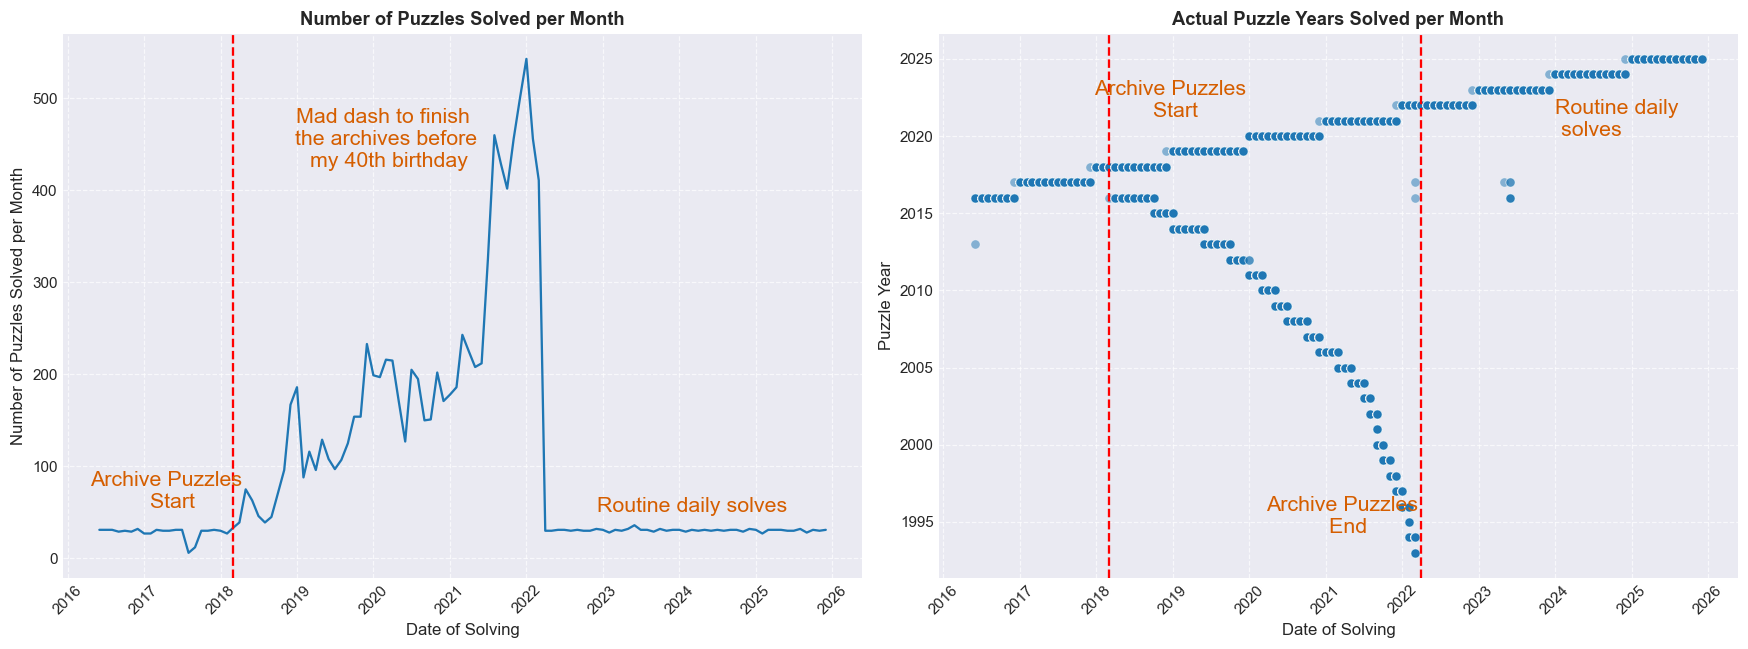

In [38]:
#@title Compute monthly solve statistics
df_temp = df.copy()

# Assign each SolveDate to the beginning of the month
df_temp['MonthStart'] = df_temp['SolveDate'].dt.to_period('M').dt.start_time

# Extract the year from PuzzleDate for calculating average year
df_temp['PuzzleYear'] = df_temp['PuzzleDate'].dt.year

# Group by MonthStart and calculate the number of puzzles and average puzzle year
monthly_stats = df_temp.groupby('MonthStart').agg(
    num_puzzles_solved=('PuzzleDate', 'count'),
    avg_puzzle_year=('PuzzleYear', 'mean')
).reset_index()

plt.figure(figsize=(16, 6))

# Plot 1: Number of Puzzles Solved per Month
ax1 = plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.lineplot(x='MonthStart', y='num_puzzles_solved', data=monthly_stats)
plt.title('Number of Puzzles Solved per Month')
plt.xlabel('Date of Solving')
plt.ylabel('Number of Puzzles Solved per Month')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotation
archive_start_date = pd.Timestamp('2018-03-01')
ax1.axvline(x=archive_start_date, color='red', linestyle='--', linewidth=1.5)
ax1.text(archive_start_date - pd.DateOffset(months=10), 50, 'Archive Puzzles \n Start', rotation=0, va='bottom', ha='center', color='#D55E00', fontsize=14)
ax1.text(pd.Timestamp('2020-03-01'), 425, 'Mad dash to finish \n the archives before \n my 40th birthday', ha = 'center', color = '#D55E00', fontsize = 14)
ax1.text(pd.Timestamp('2024-03-01'), 50, 'Routine daily solves', ha = 'center', color = '#D55E00', fontsize = 14)

# Plot 2: Actual Years of Solved Puzzles per Month (Scatter Plot)
ax2 = plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x='MonthStart', y='PuzzleYear', data=df_temp, alpha=0.5, ax=ax2)
plt.title('Actual Puzzle Years Solved per Month')
plt.xlabel('Date of Solving')
plt.ylabel('Puzzle Year')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotations
ax2.axvline(x=archive_start_date, color='red', linestyle='--', linewidth=1.5)
ax2.text(archive_start_date + pd.DateOffset(months=10), 2021, 'Archive Puzzles \n Start', rotation=0, va='bottom', ha='center', color='#D55E00', fontsize=14)
archive_end_date = pd.Timestamp('2022-04-01')
ax2.axvline(x=archive_end_date, color='red', linestyle='--', linewidth=1.5)
ax2.text(archive_end_date - pd.DateOffset(months=12), 1994, 'Archive Puzzles \n End', rotation=0, va='bottom', ha='center', color='#D55E00', fontsize=14)
ax2.text(pd.Timestamp('2024-01-01'), 2020, 'Routine daily \n solves', color = '#D55E00', fontsize = 14)

plt.tight_layout()
plt.show()

You can see the pattern of solving in the plots above. From 2016, I have been solving the day's crossword live (the diagonal line at the top of the second plot). I started solving the archives in March 2018 (red dotted line) and went on till April 2022 going back sequentially in time (hence the monotonically dropping curve between the two dotted lines). In retrospect, this modeling exercise might have been better served had I randomized this archival solve. We will see why later on.

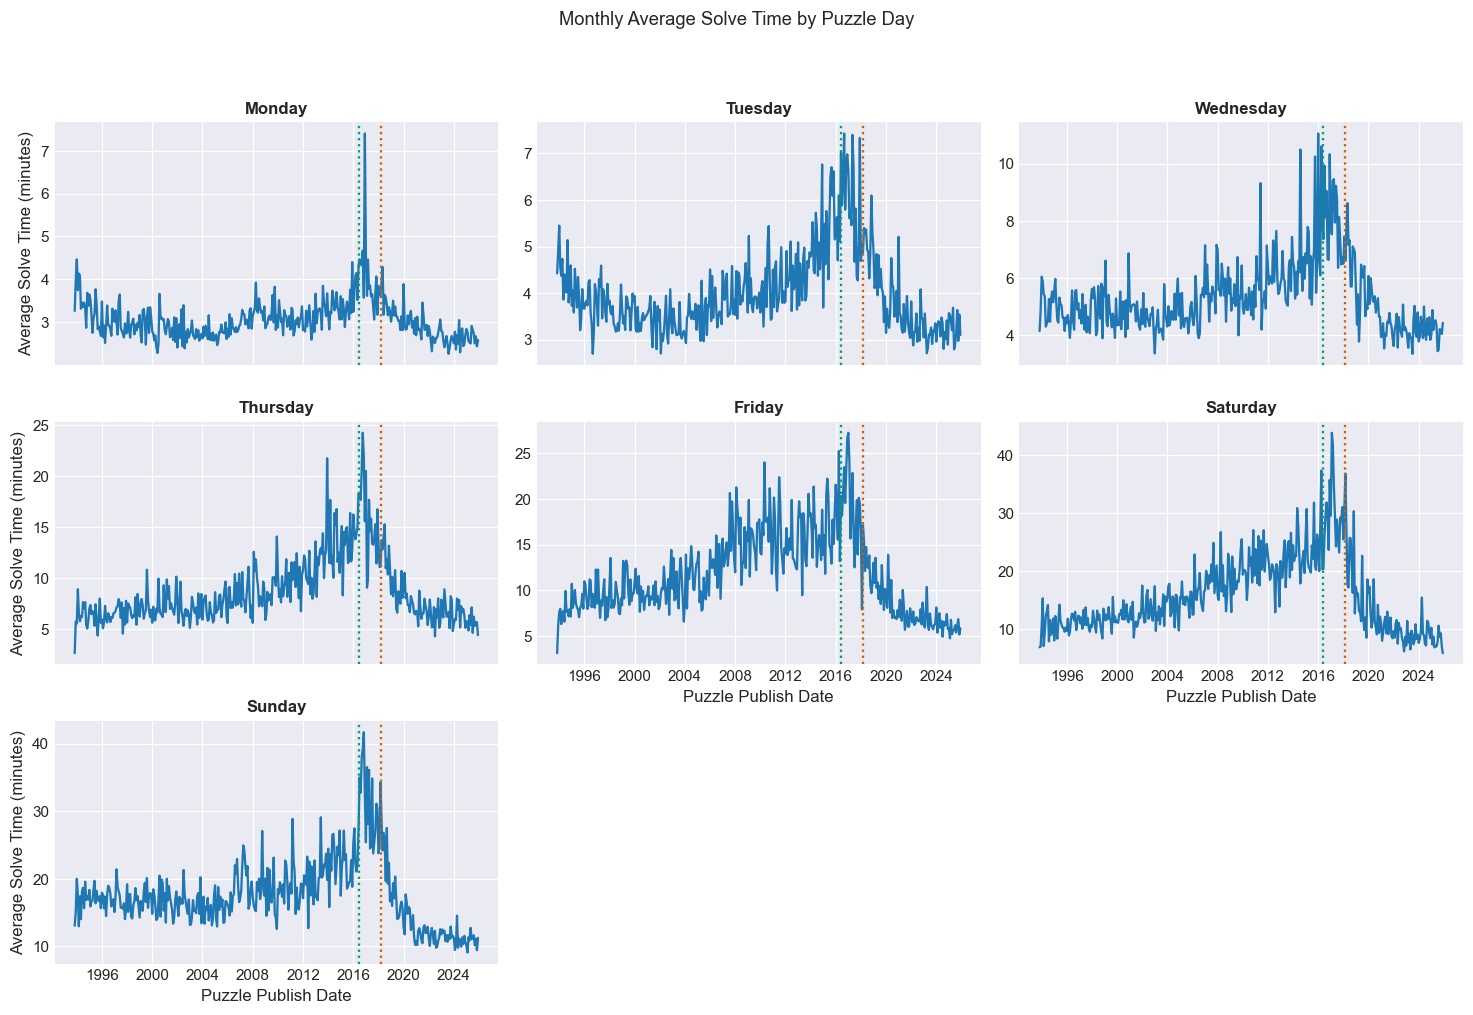

In [39]:
#@title How are my solve times looking?
# Calculate monthly start date from PuzzleDate
df['PuzzleMonthStart'] = df['PuzzleDate'].dt.to_period('M').dt.start_time

# Group by PuzzleMonthStart and PuzzleDay and calculate mean SolveTime
monthly_avg_solve_time = df.groupby(['PuzzleMonthStart', 'PuzzleDay'])['SolveTime'].mean().reset_index()
monthly_avg_solve_time['SolveTime_minutes'] = monthly_avg_solve_time['SolveTime'] / 60 # Convert SolveTime from seconds to minutes

# Define the order of days for consistent plotting
puzzle_day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
monthly_avg_solve_time['PuzzleDay'] = pd.Categorical(monthly_avg_solve_time['PuzzleDay'], categories=puzzle_day_order, ordered=True)

# Create a FacetGrid to plot for each PuzzleDay
g = sns.relplot(
    data=monthly_avg_solve_time,
    x='PuzzleMonthStart',
    y='SolveTime_minutes',
    col='PuzzleDay',
    col_wrap=3, # Wrap columns after 3 plots
    kind='line',
    height=3, aspect=1.5,
    facet_kws={'sharey': False, 'sharex': True}
)

g.set_axis_labels('Puzzle Publish Date', 'Average Solve Time (minutes)')
g.set_titles('{col_name}')
#g.set_xticklabels(rotation=45, ha='right')

# Add vertical dotted line for archive_start_date
xword_start_date = pd.Timestamp('2016-06-01')
for ax in g.axes.flat:
  ax.axvline(x=xword_start_date, color='#009E73', linestyle=':', linewidth=1.5)
  ax.axvline(x=archive_start_date, color='#D55E00', linestyle=':', linewidth=1.5)

plt.suptitle('Monthly Average Solve Time by Puzzle Day', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

This plot shows my average monthly solve times. Note that the y-axis is different for different days reflecting the widely varying difficulty levels across the days. The green dotted line was when I started solving and the red line is when I started going back in time and solving the archives (along with solving the daily puzzles)

We can see that solve times are relatively poor but slowly improving in the initial days (near the green dotted line). From March 2018 (red dotted line), I am solving both forwards in time (every day's puzzle) and backwards in time (going back sequentially into the archive). Gratifyingly, the solve times start going down in both directions.

We can also see that the improvement in solve times is higher in the forward direction than in the backward direction. That means that my improvements are more apparent on the daily solves than on the archival solves. In fact, for Mondays and Tuesdays, the performance even starts deteriorating for pre-2000 puzzles. This is puzzle fustiness in action - I was solving these puzzles in 2021-22 with the benefit of 15 years of archival solves behind me and still found the pre-2000 puzzles significantly harder than puzzles of more recent vintage.

These plots are already telling us that to measure underlying ability, we need to control for day of week and puzzle fustiness.

The table below bears out the same trends in the aggregate as well (note that this includes only daily solves and not the archive solves). The overall average is not particularly meaningful (it will be dominated by the late-week puzzle times) but is still comparable across years.

| **year** | Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | Sunday | Overall |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **2016** | 4:37 | 5:46 | 8:18 | 19:25 | 22:44 | 32:00 | 36:54 | 22:41 |
| **2017** | 3:28 | 5:38 | 8:19 | 16:26 | 18:19 | 35:35 | 32:17 | 21:05 |
| **2018** | 3:46 | 5:31 | 6:53 | 13:20 | 13:43 | 32:24 | 25:55 | 16:15 |
| **2019** | 2:57 | 4:05 | 5:18 | 8:33 | 10:05 | 15:22 | 17:00 | 10:31 |
| **2020** | 2:53 | 3:40 | 5:30 | 7:54 | 9:01 | 14:26 | 14:24 | 8:17 |
| **2021** | 2:55 | 3:28 | 4:14 | 6:27 | 6:58 | 12:06 | 11:57 | 8:04 |
| **2022** | 2:40 | 3:20 | 4:25 | 6:38 | 6:49 | 9:56 | 11:01 | 6:21 |
| **2023** | 2:36 | 2:60 | 3:48 | 5:36 | 7:08 | 10:18 | 11:38 | 6:41 |
| **2024** | 3:02 | 3:04 | 3:49 | 7:06 | 6:45 | 10:25 | 10:34 | 6:49 |
| **2025** | 2:40 | 3:03 | 3:48 | 5:44 | 6:22 | 8:34 | 10:39 | 5:54 |

Note that $2022$ seems like a high-point from this perspective with a plateauing and even a slight degradation beyond that point. It will be curious to see if the models can capture this effect.

<a id="ols"></a>
[&#8593; Back to top](#top)

## A Simple OLS Model

Let us start by building a simple OLS model that captures the basic dynamics of the problem. We will add more complexity to this model as we go on.

### Dependent variable

In this model (and in the models that follow), the dependent variable will be $\log(\text{solve time})$. Thus, all effects we measure will be multiplicative. For instance, Tuesdays will take $X$ times as long (multiplicative) compared to Mondays rather than taking $Y$ minutes longer (additive).

### Feature engineering

The independent variables for our model are day of week (fixed-effect with one dummy per day), whether a given puzzle is an archival solve or not (a single binary indicator), some basic puzzle attributes (more on this below), the publishing year of the puzzle (which is a proxy for fustiness) and the main object of interest, crossword solving ability.

**Puzzle Difficulty**: I found some datasets that provide all the clues and answers for all published NYT crosswords. I used this to devise a couple of metrics that capture a puzzle's difficulty level. The metrics I created are average word length (harder puzzles are likely to have open grids with many long words) and average word rarity. The latter is difficult to measure or even define precisely because crosswords have their own vocabulary and often feature words that are never encountered in the wild. I have chosen to use the scrabble score of a word as a proxy for its "toughness" (which is also questionable because, the presence of a rare letter in a word often opens up the grid since it imposes severe constraints on letters around it) and taking the 90th percentile of scrabble scores across all words of the grid as an attribute of that grid.

**Ability**: We will model ability using cubic splines - these are basis functions with certain desirable properties (continuity, continuous first and second derivates at the knots, linearity beyond the boundary) with uniformly spaced knots. We will model ability as $A(t) = \sum_i \eta_i B_i(t)$ with the basis weights $\eta_i$ estimated as OLS coefficients.

In [40]:
#@title Create features

day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
               'Friday': 4, 'Saturday': 5, 'Sunday': 6}

log_solve_time = np.log(df['SolveTime'].values)

# Ability is modelled with a cubic-regression spline of calendar time
ABILITY_SPLINE_DF = 8  # Could eventually be determined using 2026 validation data

reference_date = df['SolveDate'].min()
calendar_time = (df['SolveDate'] - reference_date).dt.days / 365.25

ability_basis_raw = dmatrix(f"cr(t, df={ABILITY_SPLINE_DF}) - 1", {"t": calendar_time}, return_type="dataframe")
ability_basis_design_info = ability_basis_raw.design_info  # keep for reconstructing the curve on a grid later

# Drop one spline column since a natural cubic spline's basis functions sum to exactly 1 in every row
ability_basis = ability_basis_raw.iloc[:, 1:].copy()
ability_basis.columns = [f"ability_spline_{i}" for i in range(ability_basis.shape[1])]

print(f"Ability spline basis: {ability_basis.shape[1]} columns (1 dropped to avoid intercept collinearity), "
      f"calendar time spans {calendar_time.min():.2f} to {calendar_time.max():.2f} years.")
print("---"*20)

# Day of Week
day_dummies = pd.get_dummies(df['PuzzleDay'], prefix='day').astype(float)
day_dummies = day_dummies.drop(columns=['day_Monday'])
day_dummies = day_dummies[[f"day_{d}" for d in day_mapping if d != 'Monday']]  # fix column order
print(f"Day dummies: {list(day_dummies.columns)}")
print("---"*20)

# Fustiness (piecewise-linear hinge, same knots as the Bayesian model)
FUSTY_KNOT_RECENT = 2018   # no penalty at/after this year since puzzles are essentially modern
FUSTY_KNOT_OLD = 2010      # Puzzles get noticeably older prior to this point
publish_year = df['PuzzleDate'].dt.year.values.astype(float)
fustiness_terms = pd.DataFrame(index=df.index)
fustiness_terms['gap_since_recent_knot'] = np.maximum(0.0, FUSTY_KNOT_RECENT - publish_year)
fustiness_terms['gap_since_old_knot'] = np.maximum(0.0, FUSTY_KNOT_OLD - publish_year)
print('Sample fustiness terms:')
print(fustiness_terms.head())
print("---"*20)

# Puzzle attributes (AvgWordLen, P90ScrabbleScore)
attribute_terms = df[continuous_features].copy()
print('Sample puzzle attribute terms:')
print(attribute_terms.head())
print("---"*20)

# Indicator for archival solving
solve_lag_days = (df['SolveDate'] - df['PuzzleDate']).dt.days.values
ARCHIVE_LAG_THRESHOLD_DAYS = 30  # Except for archives, I solved puzzles on the same day or a day or two later
is_archive_solve = (solve_lag_days > ARCHIVE_LAG_THRESHOLD_DAYS).astype(int)
archive_terms = pd.DataFrame(index=df.index)
archive_terms['is_archive_solve'] = is_archive_solve.astype(float)
print(f"{is_archive_solve.sum()} / {len(is_archive_solve)} historic rows flagged as archive solves "
      f"(lag > {ARCHIVE_LAG_THRESHOLD_DAYS} days).")
print("---"*20)


Ability spline basis: 7 columns (1 dropped to avoid intercept collinearity), calendar time spans 0.00 to 9.58 years.
------------------------------------------------------------
Day dummies: ['day_Tuesday', 'day_Wednesday', 'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday']
------------------------------------------------------------
Sample fustiness terms:
   gap_since_recent_knot  gap_since_old_knot
0                    2.0                 0.0
1                    2.0                 0.0
2                    5.0                 0.0
3                    2.0                 0.0
4                    2.0                 0.0
------------------------------------------------------------
Sample puzzle attribute terms:
   AvgWordLen  P90ScrabbleScore
0    4.769231             2.075
1    5.153846             3.000
2    5.175676             2.650
3    4.846154             2.130
4    5.152174             2.200
------------------------------------------------------------
8222 / 11661 his

In [41]:
#@title Fit model

X = pd.concat([ability_basis, day_dummies, fustiness_terms, attribute_terms, archive_terms], axis=1)
X = sm.add_constant(X)

ols_model = sm.OLS(log_solve_time, X).fit(cov_type="HC3")
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     3615.
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:27:09   Log-Likelihood:                -2582.9
No. Observations:               11661   AIC:                             5204.
Df Residuals:                   11642   BIC:                             5344.
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     4.40

The coefficients are largely along expected lines.

**Ability splines**: Reassuringly, the splines all have negative coefficients (which implies that ability has a subtractive effect on solve times, i.e., ability improves with time).

**Day of Week**: Days get progressively difficult as is expected. They let us conclude broad patterns - for example, all else being equal, we can conclude that it takes me $e^{0.2398} -1 = 27\%$ longer to finish a Tuesday puzzle compared to a Monday puzzle. This aligns reasonably well with the raw numbers from the dataset as the table below shows.

| Day of Week | Average Solve Time | Index wrt Monday | $\exp({\text{Coeff}})$ |
| :---: | :---: | :---: | :---: |
| **Monday** | 3:04 | 1.0 |  |
| **Tuesday** | 4:00 | 1.306 | 1.271 |
| **Wednesday** | 5:19 | 1.734 | 1.650 |
| **Thursday** | 8:39 | 2.824 | 2.457 |
| **Friday** | 11:45 | 3.836 | 2.911 |
| **Saturday** | 15:45 | 5.142 | 3.793 |
| **Sunday** | 17:40 | 5.769 | 4.958 |

The coefficients are roughly in the right ballpark but there are differences which widen with day of week. This is because there are other variables in the system (puzzle attributes) that soak up some of the variance of those solves.

**Puzzle Attributes**: Both coefficients are positive which makes sense. Puzzles with longer and/or rarer words are harder to complete.

**Is Archive Solve**: All else being equal, archive puzzles take around $e^{0.1699} - 1 = 18.5\%$ longer to solve. Note that this is an intercept effect that applies equally across all archive puzzles. We hoped for more fine grained control ("fustiness increases with puzzle age") from the fustiness terms but unfortunately...

**Fustiness** doesn't seem to work well. Both coefficients are insignificant and have relatively small effect. More on this below.

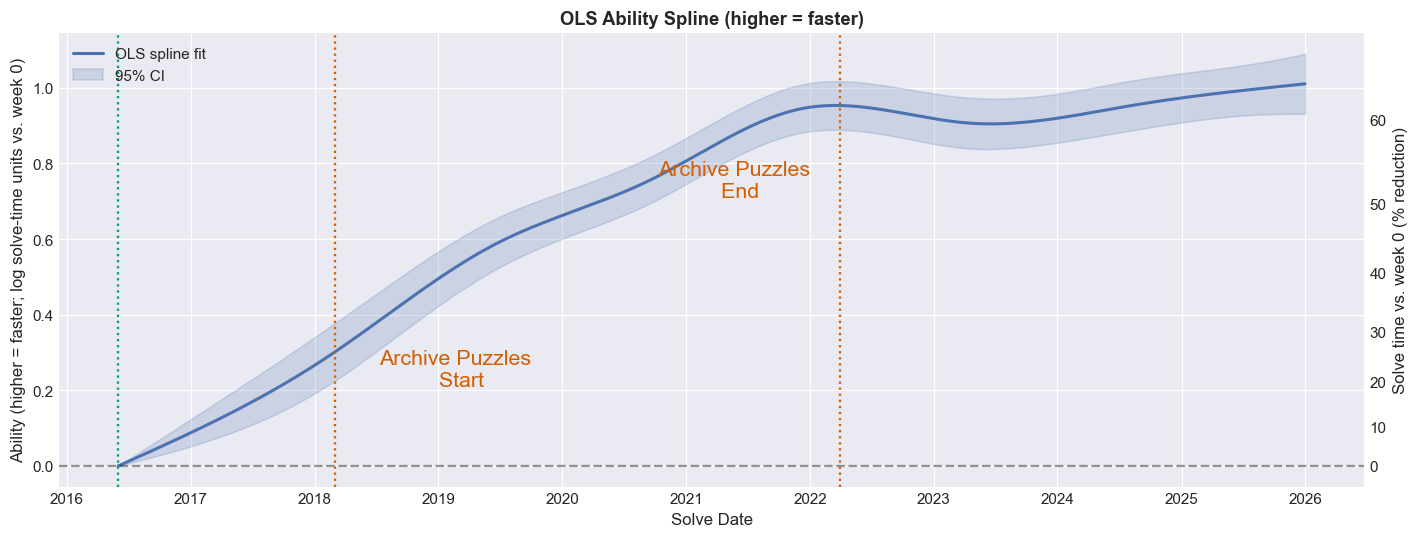

(<Figure size 1430x550 with 1 Axes>,
 <Axes: title={'center': 'OLS Ability Spline (higher = faster)'}, xlabel='Solve Date', ylabel='Ability (higher = faster; log solve-time units vs. week 0)'>)

In [42]:
#@title Visualize OLS Model Findings - Ability

def linear_combo_with_se(model, basis_df, param_names):
    """Mean and SE of basis_df @ beta[param_names], accounting for the
    covariance between those coefficients. Exact for a linear combination of
    OLS (or MixedLM fixed-effect) parameters."""
    beta_subset = model.params[param_names].values
    cov_subset = model.cov_params().loc[param_names, param_names].values
    mean = basis_df.values @ beta_subset
    var = np.einsum('ij,jk,ik->i', basis_df.values, cov_subset, basis_df.values)
    return mean, np.sqrt(np.clip(var, 0, None))


# Smooth calendar grid + spline basis. Built ONCE here and reused by the
# mixed-effects ability plot (the original notebook rebuilt this verbatim).
t_grid = np.linspace(calendar_time.min(), calendar_time.max(), 300)
date_grid = reference_date + pd.to_timedelta(t_grid * 365.25, unit='D')
_ability_grid_basis = dmatrix(ability_basis_design_info, {"t": t_grid},
                              return_type="dataframe").iloc[:, 1:]
_ability_grid_basis.columns = ability_basis.columns


def ability_from_splines(model):
    """(mean, se) of the ability curve for an OLS / MixedLM fit.
    Sign is flipped so that 'faster' reads as higher ability."""
    mean, se = linear_combo_with_se(model, _ability_grid_basis, list(ability_basis.columns))
    return -mean, se


def plot_ability_curve(dates, mean, lo, hi, title, label, color, annotate=False):
    """Shared ability-trajectory plot (used for OLS, mixed effects and Bayesian).
    Adds a right-hand axis showing the day-independent % reduction in solve time,
    1 - exp(-ability). It is multiplicative, so it does NOT depend on the day of
    week -- absolute minutes saved would."""
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(dates, mean, color=color, lw=2, label=label)
    ax.fill_between(dates, lo, hi, color=color, alpha=0.2, label="95% CI")
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Solve Date")
    ax.set_ylabel("Ability (higher = faster; log solve-time units vs. week 0)")
    # Right axis: day-independent % reduction in solve time = 1 - exp(-ability).
    _to_pct = lambda a: 100.0 * (1.0 - np.exp(-np.asarray(a, dtype=float)))
    _from_pct = lambda s: -np.log(1.0 - np.clip(np.asarray(s, dtype=float), None, 99.9) / 100.0)
    secax = ax.secondary_yaxis('right', functions=(_to_pct, _from_pct))
    secax.set_ylabel("Solve time vs. week 0 (% reduction)")
    if annotate:
        ax.axvline(x=xword_start_date, color=PALETTE['start'], linestyle=':', linewidth=1.5)
        ax.axvline(x=archive_start_date, color=PALETTE['archive'], linestyle=':', linewidth=1.5)
        ax.axvline(x=archive_end_date, color=PALETTE['archive'], linestyle=':', linewidth=1.5)
        ax.text(archive_start_date + pd.DateOffset(months=12), 0.2, 'Archive Puzzles \n Start', rotation=0, va='bottom', ha='center', color=PALETTE['archive'], fontsize=14)
        ax.text(archive_end_date - pd.DateOffset(months=10), 0.7, 'Archive Puzzles \n End', rotation=0, va='bottom', ha='center', color=PALETTE['archive'], fontsize=14)
    ax.legend(loc='upper left')
    fig.tight_layout()
    plt.show()
    return fig, ax


ability_mean_OLS, ability_se_OLS = ability_from_splines(ols_model)
plot_ability_curve(
    date_grid, ability_mean_OLS,
    ability_mean_OLS - 1.96 * ability_se_OLS,
    ability_mean_OLS + 1.96 * ability_se_OLS,
    "OLS Ability Spline (higher = faster)", "OLS spline fit",
    PALETTE['ols'], annotate=True,
)


This is encouraging!!! Ability has been increasing fairly consistently over the solve duration and beyond. All else being equal, my solve time for a puzzle in week $w$ is given by $t_w = t_0 \exp(-\text{ability}_w)$ where $t_0$ is the time I would have taken to solve the same puzzle in week $0$. The $\%$ reduction in solve time is then $\frac{t_0 - t_w}{t_0} = 1-\exp(-\text{ability}_w)$. The secondary axis on the right shows this % time saved. 

Ability at the turn of $2020$ is around $0.65$ and at the end of $2025$ is around 1.0. This means that 
$$ \begin{aligned}
\frac{t_{2025}}{t_{2020}} &= \frac{t_0 \exp(-\text{ability}_{2025})}{t_0 \exp(-\text{ability}_{2020})} \\
&= \exp(\text{ability}_{2020} - \text{ability}_{2025}) \\
&= \exp(0.65 - 1.0) = \exp(-0.35) \approx 0.7 
\end{aligned} $$

This broadly aligns with the patterns in the raw data. My average time in 2020 and 2025 are $\text{8:17}$ and $\text{5:54}$ respectively and that corresponds to a ratio of $354/497 = 0.71$. 

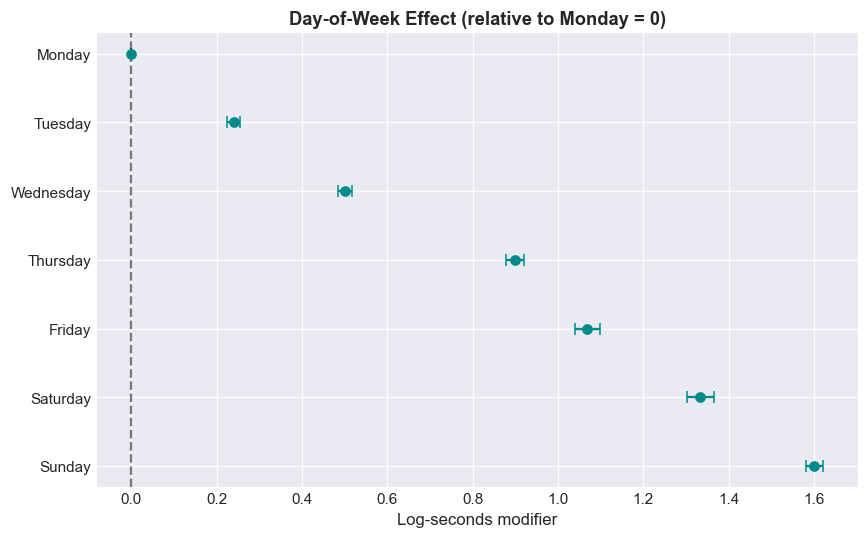

In [43]:
#@title Visualize OLS Model Findings - Day of Week
day_cols = list(day_dummies.columns)

day_coef = [0.0] + [ols_model.params[c] for c in day_cols]          # Monday = 0, matching the Bayesian baseline
day_ci_lo = [0.0] + [ols_model.conf_int().loc[c, 0] for c in day_cols]
day_ci_hi = [0.0] + [ols_model.conf_int().loc[c, 1] for c in day_cols]

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(7)
xerr = [np.array(day_coef) - np.array(day_ci_lo), np.array(day_ci_hi) - np.array(day_coef)]
ax.errorbar(day_coef, y_pos, xerr=xerr, fmt='o', color='darkcyan', capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(day_labels_full)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.invert_yaxis()
ax.set_title("Day-of-Week Effect (relative to Monday = 0)")
ax.set_xlabel("Log-seconds modifier")
plt.tight_layout()
plt.show()

There is a very strong "day of week" signal in the data. New York Times goes through considerable editorial pains to ensure that difficulty is calibrated accurately for each day and we have enough days in the dataset to ride out any stochasticity. Accordingly, we get very tight error bars here.

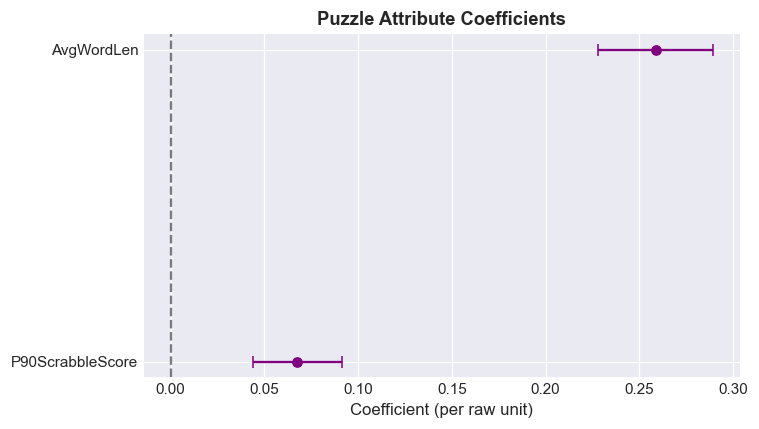

In [44]:
#@title Visualize OLS Model Findings - Puzzle Attributes
attr_coef = [ols_model.params[c] for c in continuous_features]
attr_ci_lo = [ols_model.conf_int().loc[c, 0] for c in continuous_features]
attr_ci_hi = [ols_model.conf_int().loc[c, 1] for c in continuous_features]

fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(continuous_features))
xerr = [np.array(attr_coef) - np.array(attr_ci_lo), np.array(attr_ci_hi) - np.array(attr_coef)]
ax.errorbar(attr_coef, y_pos, xerr=xerr, fmt='o', color='purple', capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(continuous_features)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.invert_yaxis()
ax.set_title("Puzzle Attribute Coefficients")
ax.set_xlabel("Coefficient (per raw unit)")
plt.tight_layout()
plt.show()


I was somewhat skeptical of these features since they are quite coarse (a puzzle might have a low AvgWordLen but with a couple of long answers that make it very difficult etc.) and they are correlated with day of week. I was pleasantly surprised to find that both effects are positive and with error bars away from $0$.  

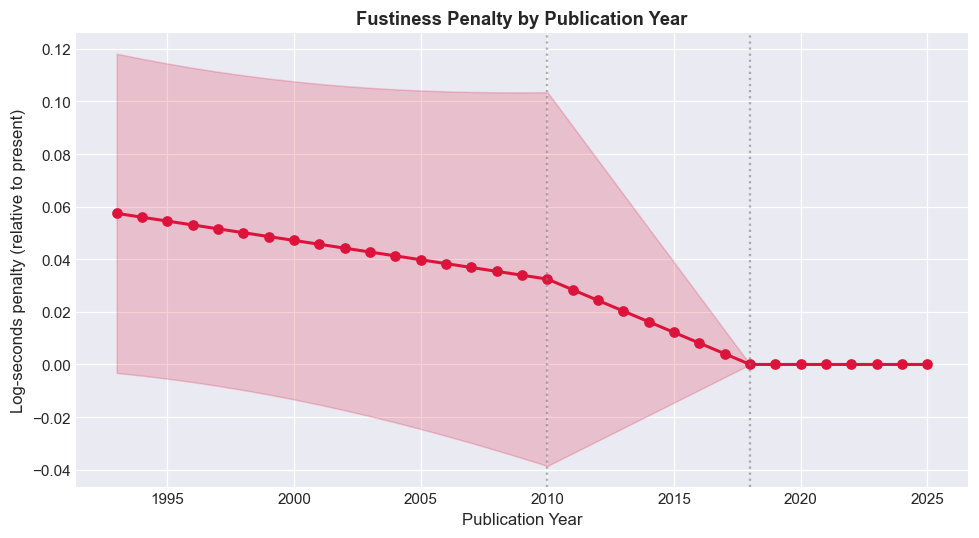

In [45]:
#@title Visualize OLS Model Findings - Puzzle Fustiness
year_grid = np.arange(df['PuzzleDate'].dt.year.min(), df['PuzzleDate'].dt.year.max() + 1)
fusty_grid = pd.DataFrame({
    'gap_since_recent_knot': np.maximum(0.0, FUSTY_KNOT_RECENT - year_grid.astype(float)),
    'gap_since_old_knot': np.maximum(0.0, FUSTY_KNOT_OLD - year_grid.astype(float)),
})

fusty_mean, fusty_se = linear_combo_with_se(
    ols_model, fusty_grid, ['gap_since_recent_knot', 'gap_since_old_knot']
)

plt.figure(figsize=(9, 5))
plt.plot(year_grid, fusty_mean, color="crimson", marker='o', lw=2)
plt.fill_between(year_grid, fusty_mean - 1.96 * fusty_se, fusty_mean + 1.96 * fusty_se,
                  color="crimson", alpha=0.2)
plt.axvline(FUSTY_KNOT_OLD, color='gray', linestyle=':', alpha=0.6)
plt.axvline(FUSTY_KNOT_RECENT, color='gray', linestyle=':', alpha=0.6)
plt.title("Fustiness Penalty by Publication Year")
plt.xlabel("Publication Year")
plt.ylabel("Log-seconds penalty (relative to present)")
plt.tight_layout()
plt.show()


Fustiness does not work at all. This is a weak effect at best with huge CI. Even the directionality of fustiness is quite fragile and goes the wrong way if model specifications change a bit (like changing the number of knots in the spline).

### Why is Fustiness difficult to measure?

It turns out there is a data-driven reason that makes puzzle fustiness difficult to measure. It has to do with the order in which I solved the archive puzzles.

There is a fundamental tension between fustiness and ability - they impact solving time in opposite ways (am I slow because the puzzle is fusty or because my ability is limited?). To truly disambiguate between them, we need data in all 4 buckets.

|  | Low Ability | High Ability |
| :--- | :---: | :---: |
| **Low fustiness** | Daily puzzles solved early <br> in the solving journey (2017-18) <br> <br> Relatively few puzzles in the data | Daily solves from 2022 onwards <br> when my ability has roughly plateaued <br> <br> Well represented in the data |
| **High fustiness** | Very old puzzles solved <br> early in the solving journey <br> <br> No such puzzles in the data | Puzzles solved towards the end <br> of the archival solve period (2021-22) <br> <br> Well represented in the data |

As we can see, we only have data in two regimes:
*   (high ability, low fustiness)  - daily solves from say 2023 onwards. Here, the two dimensions are working in tandem to reduce solve times - puzzles are smooth/topical _and_ my skill levels are high.
*   (high ability, high fustiness) - archive solves of pre-2000 puzzles in 2021-22. Here, the two dimensions are working in opposition - the puzzles are quite dated and might prove challenging despite my increased solving ability.

Ability and fustiness are not highly correlated in the data but it is the next worst thing. There are two regimes and the two variables are either highly correlated or perfectly anti-correlated in these two regimes. Given this structural issue, any modeling form is going to struggle to disambiguate their effects and we will see this play out across all model forms.


There are some ways to break out of this correlation trap that I will discuss towards the end. But now, let us move to a more sophisticated model form that allows us to bring more information into the modeling framework.

<a id="mixed"></a>
[&#8593; Back to top](#top)

## Mixed-effect Modeling

### Motivation

One crucial piece of information that we haven't used thus far in modelling is the constructor of the puzzle. If a constructor is known to be tough, solve times on their puzzles are likely to be longer than average. This feels like useful information to include in the model but there are some problems:
*   There are thousands of constructors in the data and it is impractical (and impossible) to model all of them using OLS (where each of them would be given a dummy variable)
*   Even if we were willing to do that, the quality of data will vary widely across constructors. Some constructors will have many puzzles which allows us to learn their "style". Most will have only one puzzle and that will tell us nothing.
*   There is a fundamental technical limitation beyond these sample size limitations - OLS assumes that all errors are uncorrelated, an assumption that will be violated with constructors in the model. If a constructor has $20$ puzzles and has a very difficult style compared to the average, the $20$ errors in those $20$ observations will all be higher than average - in other words, they would be correlated. OLS is not equipped to deal with this correlation which in turn will make the confidence intervals of OLS estimates overly optimistic. Roughly, this correlation structure brings down the effective sample size. We no longer have $N$ independent pieces of observations but OLS does not know this and will continue to use $N$ in the denominator for variance estimates of the type $\sigma^2/N$ (again, roughly) when it should be dividing by some $M < N$. This results in smaller errors when correlated data is estimated using OLS.

How can we bring this information into the model robustly?

<a id="next"></a>
[&#8593; Back to top](#top)

## What next

There are many ways in which this apparatus can be extended.

*   **Interaction**: We can think about ability as measuring the multiplicative decrease in run-times with increasing skill. But it is not equally easy to achieve the same multiplicative effect on all days of the week. It is easier to achieve a $10\%$ reduction on Saturday times compared to Monday times simply because there is that much less headroom with Mondays. This suggests that ability should be estimated in conjunction with day of week rather than independently. 
*   **Re-solving**: Suppose I randomly resolve a fraction of the puzzles and log the new times. The only change between the solve times is the change in my ability (all other variables like constructor style, puzzle attributes etc. stay the same). This gives us another signal to accurately peg ability and therefore better estimate the other parameters. Not so fast though - my re-solve times might be better simply because I remember the puzzle from before!!! Not all time improvements can be chalked up to my ability. We can account for this memory through a "forgetting curve" whose parameters can also be estimated using the Bayesian apparatus (jointly along with all other parameters above).
*   **Community solve times**: This can be a genuinely interesting signal completely independent of my individual ability. If we know community solve times, that is an independent and clean proxy for puzzle difficulty, something that the puzzle attributes in the current model are only scratching the surface of. If everyone in the community takes too long to finish a puzzle, my slow solve time is not an indictment of my ability. This data is hard to source but it would be very interesting to work with.